In [20]:
import nn_tilde
import torch
import cached_conv as cc
from after.autoencoder import AutoEncoder

import gin

gin.enter_interactive_mode()
from absl import app, flags
import os

model_path = "/data/nils/repos/AFTER/after_ae_runs/drumsv2"
step = 1100000


class AE_causal(torch.nn.Module):

    def __init__(self) -> None:
        super().__init__()

        config = os.path.join(model_path, "config.gin")

        with gin.unlock_config():
            gin.parse_config_files_and_bindings(
                [config],
                [],
            )

        sr = gin.query_parameter("%SR")

        model = AutoEncoder()
        d = torch.load(
            os.path.join(model_path, "checkpoint" + str(step) + ".pt"))
        model.load_state_dict(d["model_state"])

        self.model = model

        test_array = torch.zeros((3, 1, 4096))
        z, _ = self.model.encode(test_array)

        self.comp_ratio = test_array.shape[-1] // z.shape[-1]

        self.latent_size = gin.query_parameter("%LATENT_SIZE")
        self.target_channels = 1

    @torch.jit.export
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.model.use_pqmf:
            x = self.model.pqmf(x)

        z = self.model.encoder(x)

        z, _ = self.model.bottleneck(z)

        x = self.model.decoder(z)

        if self.model.use_pqmf:
            x = self.model.pqmf.inverse(x)

        return x

    @torch.jit.export
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        if self.model.use_pqmf:
            x = self.model.pqmf(x)
        z = self.model.encoder(x)
        z, _ = self.model.bottleneck(z)

        return z

    @torch.jit.export
    def decode(self, z: torch.Tensor) -> torch.Tensor:
        x = self.model.decoder(z)
        if self.model.use_pqmf:
            x = self.model.pqmf.inverse(x)
        return x


In [21]:
ae = AE_causal()

/data/nils/miniconda3/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/tmp/ipykernel_1901882/2435367859.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` fo

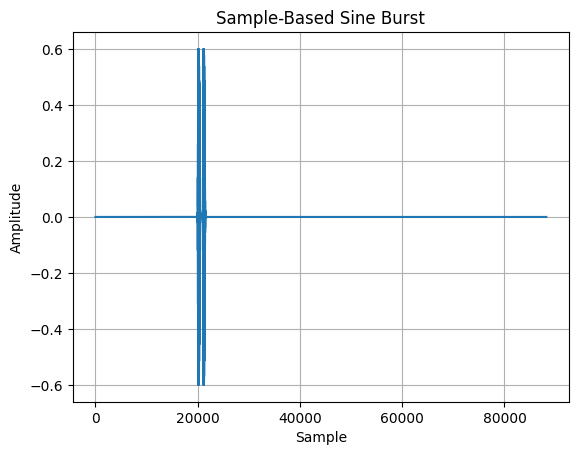

In [22]:
import torch
import math
import matplotlib.pyplot as plt  # Optional: for visualization


def generate_sine_burst_samples(
        total_samples=44100,  # total length of the output signal
        burst_start_sample=10000,  # when the burst starts (in samples)
        burst_length_samples=2205,  # length of the burst (in samples)
        fade_in_samples=100,  # fade-in length (in samples)
        fade_out_samples=200,  # fade-out length (in samples)
        frequency=1000,  # frequency of the sine wave (Hz)
        amplitude=0.5,  # amplitude
        sample_rate=44100  # sample rate for frequency calculation
):
    # Full output signal
    signal = torch.zeros(total_samples, dtype=torch.float32)

    # Determine burst sample range
    burst_end_sample = burst_start_sample + burst_length_samples
    if burst_end_sample > total_samples:
        burst_end_sample = total_samples
        burst_length_samples = burst_end_sample - burst_start_sample

    if burst_length_samples <= 0:
        return signal  # no room for burst

    # Time vector for burst
    t = torch.arange(burst_length_samples, dtype=torch.float32) / sample_rate

    # Sine burst
    burst = amplitude * torch.sin(2 * math.pi * frequency * t)

    # Envelope
    envelope = torch.ones_like(burst)

    # Apply fade-in
    fade_in_samples = min(fade_in_samples, burst_length_samples)
    if fade_in_samples > 0:
        fade_in = 0.5 * (
            1 - torch.cos(math.pi * torch.linspace(0, 1, fade_in_samples)))
        envelope[:fade_in_samples] = fade_in

    # Apply fade-out
    fade_out_samples = min(fade_out_samples, burst_length_samples)
    if fade_out_samples > 0:
        fade_out = 0.5 * (
            1 + torch.cos(math.pi * torch.linspace(0, 1, fade_out_samples)))
        envelope[-fade_out_samples:] = fade_out

    burst *= envelope

    # Insert burst into full signal
    signal[burst_start_sample:burst_end_sample] = burst

    return signal


# Example use
signal = generate_sine_burst_samples(total_samples=2 * 44100,
                                     burst_start_sample=20000,
                                     burst_length_samples=512,
                                     fade_in_samples=100,
                                     fade_out_samples=300,
                                     frequency=10000,
                                     amplitude=0.6,
                                     sample_rate=44100)

signal += generate_sine_burst_samples(total_samples=2 * 44100,
                                      burst_start_sample=21000,
                                      burst_length_samples=512,
                                      fade_in_samples=100,
                                      fade_out_samples=300,
                                      frequency=10000,
                                      amplitude=0.6,
                                      sample_rate=44100)

# Plot
plt.plot(signal.numpy())
plt.title("Sample-Based Sine Burst")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

from IPython.display import Audio

Audio(signal.numpy(),
      rate=44100)  # Play the generated signal in Jupyter Notebook

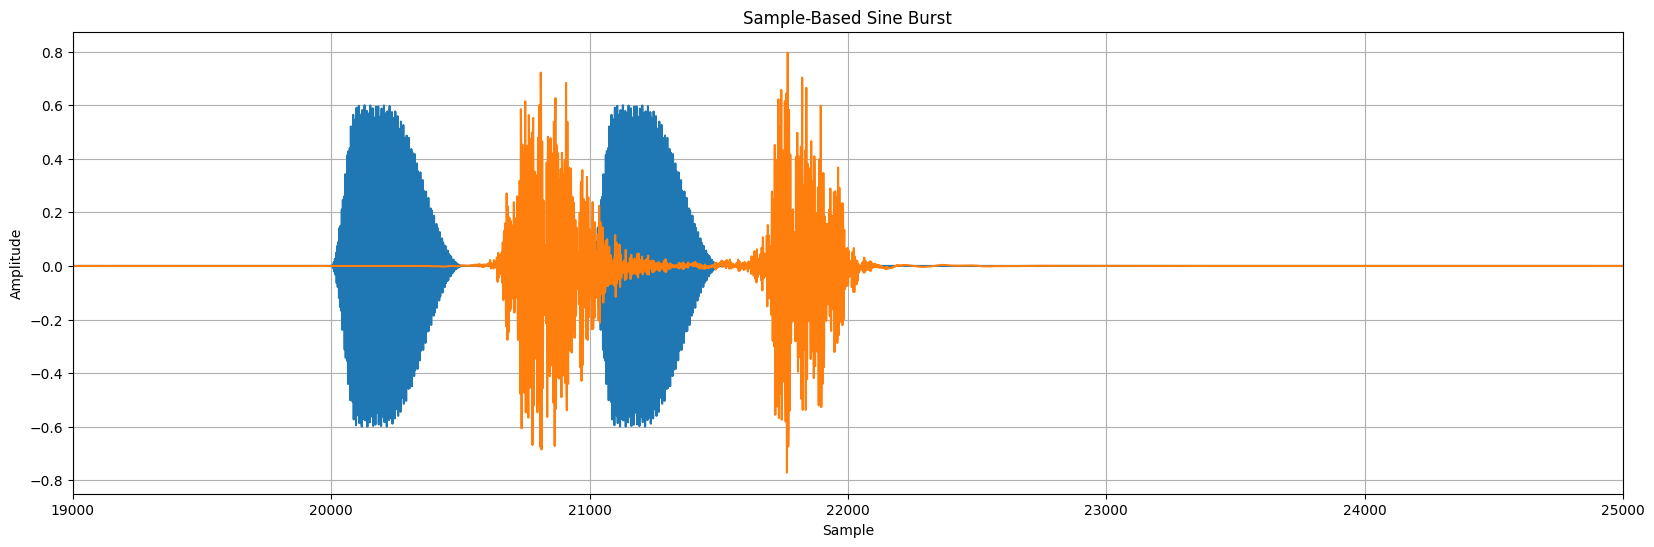

In [23]:
# z = ae.encode(signal.unsqueeze(0).unsqueeze(0))  # Add batch and channel dimensions
# audio_out = emb.decode(z)  # Add batch and channel dimensions
torch.set_grad_enabled(False)  # Disable gradients for inference
audio_out = ae(signal.unsqueeze(0).unsqueeze(0))
# Plot
plt.figure(figsize=(20, 6))
plt.plot(signal.numpy())
plt.plot(audio_out.numpy().squeeze())
plt.title("Sample-Based Sine Burst")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.xlim(19000, 25000)  # Limit x-axis for better visibility
plt.show()

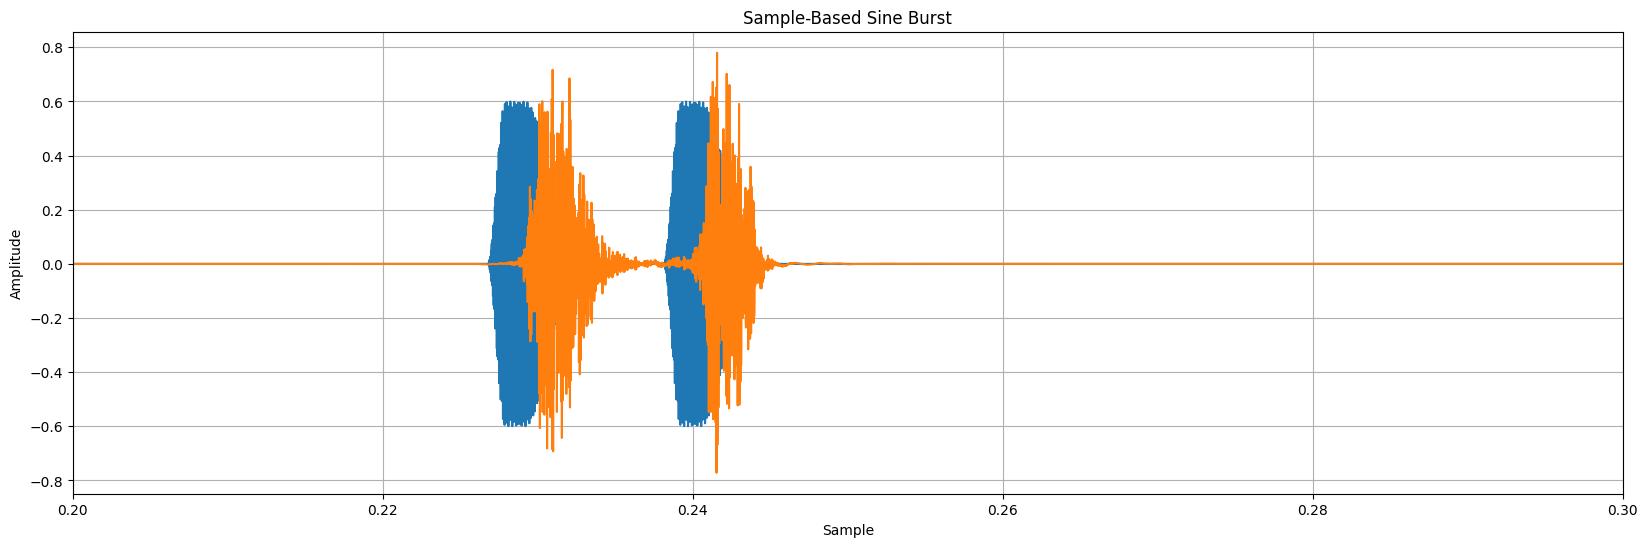

In [47]:
# z = ae.encode(signal.unsqueeze(0).unsqueeze(0))  # Add batch and channel dimensions
# audio_out = emb.decode(z)  # Add batch and channel dimensions
torch.set_grad_enabled(False)  # Disable gradients for inference
audio_out = ae.model.pqmf(signal.unsqueeze(0).unsqueeze(0))[:, 0] * 1e6
z = ae.encode(signal.unsqueeze(0).unsqueeze(0))

audio_out = ae.model.decoder(z)[0, 10] * 200
audio_out = ae.decode(z)
# Plot
plt.figure(figsize=(20, 6))
plt.plot(torch.linspace(0, 1, signal.shape[-1]), signal.numpy())
plt.plot(torch.linspace(0, 1, audio_out.shape[-1]),
         audio_out.numpy().squeeze())
plt.title("Sample-Based Sine Burst")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.xlim(0.2, 0.3)
# plt.xlim(19000, 25000)  # Limit x-axis for better visibility
plt.show()

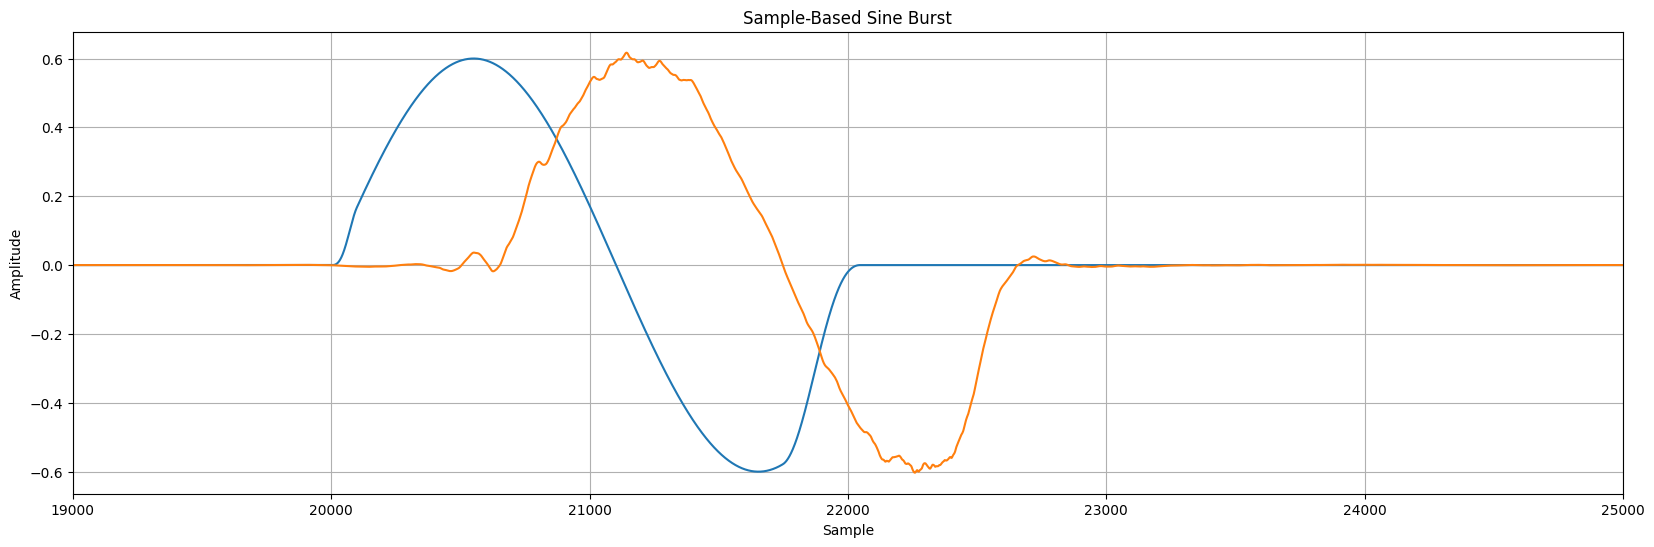

In [15]:
# z = ae.encode(signal.unsqueeze(0).unsqueeze(0))  # Add batch and channel dimensions
# audio_out = emb.decode(z)  # Add batch and channel dimensions
torch.set_grad_enabled(False)  # Disable gradients for inference
audio_out = ae(signal.unsqueeze(0).unsqueeze(0))
# Plot
plt.figure(figsize=(20, 6))
plt.plot(signal.numpy())
plt.plot(audio_out.numpy().squeeze())
plt.title("Sample-Based Sine Burst")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.xlim(19000, 25000)  # Limit x-axis for better visibility
plt.show()